# Cosmic Large `origtarget_genref` Viewer

This notebook mirrors the current `cosmic_large` dataset behavior when `train_dataset_origtarget_genref=true`.

Behavior shown here:
- target image is the top-level JSON key image
- target face mask is `face_crop_new`
- target prompt comes from `facial_caption` when it contains `img`, otherwise fallback is `A person img`
- reference image is a random entry from `face_paths`
- reference crop/mask use the same `face_bboxes` + bigger-crop logic as training

Notes:
- `APPLY_RANDOM_FLIP=False` by default for readability. Set it to `True` to mirror the dataset randomness exactly.
- In this mode the target stays `1024x1024` by default, matching the current training code.


In [1]:
from __future__ import annotations

import json
import math
import random
import re
import textwrap
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps

plt.style.use("seaborn-v0_8-whitegrid")

RNG_SEED = 42
PAIR_SAMPLE_SIZE = 20
PAIRS_PER_ROW = 4
TRAIN_IMAGE_SIZE = 1024
CROP_SCALE = 0.2
APPLY_RANDOM_FLIP = False

TARGET_DATASET_DIR = Path('/home/kolyangg/rsrch/dataset_full/LAION-5B-Filtered-Large/laion1B-nolang')
FACE_DATASET_DIR = Path('/home/kolyangg/rsrch/dataset_full/cosmic_large/LAION-5B-Filtered-Large-Faces/laion1B-nolang')
METADATA_JSON = Path('/home/kolyangg/rsrch/dataset_full/cosmic_large/gathered_data_cosmic_large_filtered_sample_two.json')
TARGET_PATH_PREFIX = 'LAION-5B-Filtered-Large/laion1B-nolang'
FACE_PATH_PREFIX = 'LAION-5B-Filtered-Large-Faces/laion1B-nolang'
PROMPT_IMG_RE = re.compile(r"\bimg\b", re.IGNORECASE)

with METADATA_JSON.open() as f:
    METADATA = json.load(f)

print({
    'metadata_records': len(METADATA),
    'target_dataset_dir': str(TARGET_DATASET_DIR),
    'face_dataset_dir': str(FACE_DATASET_DIR),
    'metadata_json': str(METADATA_JSON),
    'train_image_size': TRAIN_IMAGE_SIZE,
})


{'metadata_records': 15, 'target_dataset_dir': '/home/kolyangg/rsrch/dataset_full/LAION-5B-Filtered-Large/laion1B-nolang', 'face_dataset_dir': '/home/kolyangg/rsrch/dataset_full/cosmic_large/LAION-5B-Filtered-Large-Faces/laion1B-nolang', 'metadata_json': '/home/kolyangg/rsrch/dataset_full/cosmic_large/gathered_data_cosmic_large_filtered_sample_two.json', 'train_image_size': 1024}


In [2]:
def relative_target_path(path: str) -> str:
    path = str(path).lstrip('/')
    prefix = TARGET_PATH_PREFIX.rstrip('/') + '/'
    if path.startswith(prefix):
        return path[len(prefix):]
    marker = f"/{TARGET_DATASET_DIR.name}/"
    marked = f"/{path}"
    if marker in marked:
        return marked.split(marker, 1)[1]
    return path


def relative_face_path(face_path: str) -> str:
    face_path = str(face_path).lstrip('/')
    prefix = FACE_PATH_PREFIX.rstrip('/') + '/'
    if face_path.startswith(prefix):
        return face_path[len(prefix):]
    marker = f"/{FACE_DATASET_DIR.name}/"
    marked = f"/{face_path}"
    if marker in marked:
        return marked.split(marker, 1)[1]
    return face_path


def target_abs_path(path: str) -> Path:
    return TARGET_DATASET_DIR / relative_target_path(path)


def face_abs_path(face_path: str) -> Path:
    return FACE_DATASET_DIR / relative_face_path(face_path)


def clip_bbox_to_image(bbox, img_size):
    if bbox is None:
        return None
    img_w, img_h = img_size
    x0, y0, x1, y1 = [float(v) for v in bbox]
    clipped_bbox = [
        max(0.0, min(float(img_w), x0)),
        max(0.0, min(float(img_h), y0)),
        max(0.0, min(float(img_w), x1)),
        max(0.0, min(float(img_h), y1)),
    ]
    if clipped_bbox[2] <= clipped_bbox[0] or clipped_bbox[3] <= clipped_bbox[1]:
        return None
    return clipped_bbox


def scale_bbox_to_size(bbox, src_size, dst_size):
    if bbox is None:
        return None
    src_w, src_h = src_size
    dst_w, dst_h = dst_size
    scale_x = dst_w / max(src_w, 1)
    scale_y = dst_h / max(src_h, 1)
    x0, y0, x1, y1 = [float(v) for v in bbox]
    scaled_bbox = [x0 * scale_x, y0 * scale_y, x1 * scale_x, y1 * scale_y]
    return clip_bbox_to_image(scaled_bbox, dst_size)


def is_valid_bbox(bbox):
    if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
        return False
    x0, y0, x1, y1 = bbox
    return x1 > x0 and y1 > y0 and min(bbox) >= 0


def resolve_face_bbox(record: dict, face_path: str):
    rel_path = relative_face_path(face_path)
    bbox_map = record.get('face_bboxes') or {}
    candidates = [str(face_path), str(face_path).lstrip('/'), rel_path, rel_path.lstrip('/')]
    for candidate in candidates:
        bbox = bbox_map.get(candidate)
        if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
            return clip_bbox_to_image([float(v) for v in bbox], (256, 256))
    return None


def build_prompt(record: dict) -> str:
    facial_caption = record.get('facial_caption', '')
    if isinstance(facial_caption, str):
        facial_caption = facial_caption.strip()
        if facial_caption and PROMPT_IMG_RE.search(facial_caption):
            return facial_caption
    return 'A person img'


def basename_label(path: str) -> str:
    p = Path(str(path))
    return f"{p.parent.name}/{p.name}"


In [3]:
def get_bigger_crop_with_bbox(img, face_bbox, scale=0.2):
    crop = [int(round(v)) for v in deepcopy(face_bbox)]
    if crop[3] - crop[1] < crop[2] - crop[0]:
        diff = crop[2] - crop[0] - (crop[3] - crop[1])
        if diff % 2 != 0:
            crop[0] -= 1
            diff += 1
        crop[3] += diff // 2
        crop[1] -= diff // 2
    elif crop[2] - crop[0] < crop[3] - crop[1]:
        diff = crop[3] - crop[1] - (crop[2] - crop[0])
        if diff % 2 != 0:
            crop[1] -= 1
            diff += 1
        crop[2] += diff // 2
        crop[0] -= diff // 2

    assert crop[3] - crop[1] == crop[2] - crop[0], crop

    to_add = int((crop[3] - crop[1]) * scale)
    img_w, img_h = img.size
    crop = [
        max(0, crop[0] - to_add),
        max(0, crop[1] - to_add),
        min(img_w, crop[2] + to_add),
        min(img_h, crop[3] + to_add),
    ]
    cropped_img = img.crop((crop[0], crop[1], crop[2], crop[3]))
    cropped_bbox = [
        face_bbox[0] - crop[0],
        face_bbox[1] - crop[1],
        face_bbox[2] - crop[0],
        face_bbox[3] - crop[1],
    ]
    cropped_bbox = clip_bbox_to_image(cropped_bbox, cropped_img.size)
    return cropped_img, cropped_bbox, crop


def load_orig_target_image_and_bbox(record_key: str, record: dict):
    path = target_abs_path(record_key)
    if not path.is_file():
        raise FileNotFoundError(path)

    raw_img = Image.open(path).convert('RGB')
    bbox = deepcopy(record.get('face_crop_new'))
    if not is_valid_bbox(bbox):
        raise ValueError(f'Missing valid face_crop_new for {record_key}')
    bbox = [float(v) for v in bbox]

    img = raw_img
    body_crop = record.get('body_crop')
    if isinstance(body_crop, (list, tuple)) and len(body_crop) == 4:
        x0, y0, x1, y1 = [int(v) for v in body_crop]
        if 0 <= x0 < x1 <= raw_img.size[0] and 0 <= y0 < y1 <= raw_img.size[1]:
            img = raw_img.crop((x0, y0, x1, y1))
            bbox = [bbox[0] - x0, bbox[1] - y0, bbox[2] - x0, bbox[3] - y0]
            bbox = clip_bbox_to_image(bbox, img.size)
            if bbox is None:
                raise ValueError(f'Invalid body-cropped bbox for {record_key}')

    if img.size != (TRAIN_IMAGE_SIZE, TRAIN_IMAGE_SIZE):
        bbox = scale_bbox_to_size(bbox, img.size, (TRAIN_IMAGE_SIZE, TRAIN_IMAGE_SIZE))
        img = img.resize((TRAIN_IMAGE_SIZE, TRAIN_IMAGE_SIZE), Image.BICUBIC)

    return img, bbox, raw_img.size


def load_random_ref_image_and_bbox(record: dict, rng: np.random.Generator):
    face_paths = [str(p) for p in record.get('face_paths') or []]
    if not face_paths:
        raise ValueError('Expected non-empty face_paths')

    ref_path = str(rng.choice(face_paths))
    ref_abs = face_abs_path(ref_path)
    if not ref_abs.is_file():
        raise FileNotFoundError(ref_abs)

    ref_img_full = Image.open(ref_abs).convert('RGB')
    face_bbox = resolve_face_bbox(record, ref_path)
    if face_bbox is None:
        raise ValueError(f'Missing valid face bbox for {ref_path}')

    ref_crop, ref_bbox, ref_window = get_bigger_crop_with_bbox(ref_img_full, face_bbox, scale=CROP_SCALE)
    if ref_bbox is None:
        raise ValueError(f'Invalid ref crop bbox for {ref_path}')

    return ref_path, ref_crop, ref_bbox, ref_window, ref_img_full.size


In [4]:
eligible_records = {
    key: record
    for key, record in METADATA.items()
    if (
        isinstance(record, dict)
        and (record.get('face_paths') or [])
        and is_valid_bbox(record.get('face_crop_new'))
        and target_abs_path(key).is_file()
        and all(face_abs_path(face_path).is_file() for face_path in record.get('face_paths') or [])
    )
}

print({
    'eligible_records': len(eligible_records),
    'total_face_paths': sum(len(record.get('face_paths') or []) for record in eligible_records.values()),
})

rng = np.random.default_rng(RNG_SEED)
record_keys = sorted(eligible_records)
replace_records = len(record_keys) < PAIR_SAMPLE_SIZE
sampled_record_keys = rng.choice(record_keys, size=PAIR_SAMPLE_SIZE, replace=replace_records)

rows = []
random.seed(RNG_SEED)
for record_key in sampled_record_keys:
    record = eligible_records[str(record_key)]
    target_img, target_bbox, target_raw_size = load_orig_target_image_and_bbox(record_key, record)
    ref_path, ref_img, ref_bbox, ref_window, ref_raw_size = load_random_ref_image_and_bbox(record, rng)

    if APPLY_RANDOM_FLIP:
        if random.random() < 0.5:
            w, _ = target_img.size
            target_img = ImageOps.mirror(target_img)
            x0, y0, x1, y1 = target_bbox
            target_bbox = [w - x1, y0, w - x0, y1]
        if random.random() < 0.5:
            w, _ = ref_img.size
            ref_img = ImageOps.mirror(ref_img)
            x0, y0, x1, y1 = ref_bbox
            ref_bbox = [w - x1, y0, w - x0, y1]

    rows.append({
        'record_key': str(record_key),
        'target_path': str(record_key),
        'ref_path': ref_path,
        'target_img': target_img,
        'target_bbox': target_bbox,
        'ref_img': ref_img,
        'ref_bbox': ref_bbox,
        'prompt': build_prompt(record),
        'num_face_paths': len(record.get('face_paths') or []),
        'target_resolution': f"{target_img.size[0]}x{target_img.size[1]}",
        'ref_resolution': f"{ref_img.size[0]}x{ref_img.size[1]}",
        'target_raw_resolution': f"{target_raw_size[0]}x{target_raw_size[1]}",
        'ref_raw_resolution': f"{ref_raw_size[0]}x{ref_raw_size[1]}",
        'ref_window': ref_window,
    })

pairs_df = pd.DataFrame(rows)
print({
    'sampled_pairs': len(pairs_df),
    'apply_random_flip': APPLY_RANDOM_FLIP,
})
pairs_df[['record_key', 'target_path', 'ref_path', 'target_resolution', 'ref_resolution', 'prompt']].head()


{'eligible_records': 15, 'total_face_paths': 126}
{'sampled_pairs': 20, 'apply_random_flip': False}


,record_key,target_path,ref_path,target_resolution,ref_resolution,prompt
0,LAION-5B-Filtered-Large/laion1B-nolang/00000/1...,LAION-5B-Filtered-Large/laion1B-nolang/00000/1...,LAION-5B-Filtered-Large-Faces/laion1B-nolang/0...,1024x1024,256x256,"The woman img has long, dark brown hair, warm ..."
1,LAION-5B-Filtered-Large/laion1B-nolang/00120/1...,LAION-5B-Filtered-Large/laion1B-nolang/00120/1...,LAION-5B-Filtered-Large-Faces/laion1B-nolang/0...,1024x1024,247x256,the person img with short dark brown hair styl...
2,LAION-5B-Filtered-Large/laion1B-nolang/00120/1...,LAION-5B-Filtered-Large/laion1B-nolang/00120/1...,LAION-5B-Filtered-Large-Faces/laion1B-nolang/0...,1024x1024,256x256,"The girl img has long brown hair in a braid, y..."
3,LAION-5B-Filtered-Large/laion1B-nolang/00000/3...,LAION-5B-Filtered-Large/laion1B-nolang/00000/3...,LAION-5B-Filtered-Large-Faces/laion1B-nolang/0...,1024x1024,256x256,"The person img has short black hair, neatly st..."
4,LAION-5B-Filtered-Large/laion1B-nolang/00000/3...,LAION-5B-Filtered-Large/laion1B-nolang/00000/3...,LAION-5B-Filtered-Large-Faces/laion1B-nolang/0...,1024x1024,253x256,"The person img has short black hair, neatly st..."


In [5]:
def draw_bbox(ax, bbox, color, linewidth=2.5):
    if bbox is None:
        return
    x0, y0, x1, y1 = bbox
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=linewidth))


def wrap_to_image_width(text, image, min_chars=18, max_chars=40, px_per_char=8.0):
    image_width = image.size[0] if hasattr(image, 'size') else 256
    wrap_width = max(min_chars, min(max_chars, int(round(image_width / px_per_char))))
    wrapped_lines = []
    for line in str(text).splitlines():
        wrapped_lines.extend(
            textwrap.wrap(
                line,
                width=wrap_width,
                break_long_words=False,
                break_on_hyphens=False,
            ) or ['']
        )
    return '\n'.join(wrapped_lines)


def draw_labeled_image(ax, image, bbox, title, subtitle=None, color='#ff4d4d'):
    ax.imshow(image)
    draw_bbox(ax, bbox, color=color)
    ax.set_xticks([])
    ax.set_yticks([])
    wrapped_title = wrap_to_image_width(title, image, min_chars=18, max_chars=34, px_per_char=8.5)
    ax.set_title(wrapped_title, fontsize=9)
    if subtitle:
        wrapped_subtitle = wrap_to_image_width(subtitle, image, min_chars=18, max_chars=40, px_per_char=8.0)
        ax.text(
            0.5,
            -0.08,
            wrapped_subtitle,
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=8,
            linespacing=1.05,
        )


def show_pair_grid(df: pd.DataFrame, title: str, color_target='#11a579', color_ref='#3969ac'):
    num_pairs = len(df)
    rows = math.ceil(num_pairs / PAIRS_PER_ROW)
    fig, axes = plt.subplots(rows, PAIRS_PER_ROW * 2, figsize=(PAIRS_PER_ROW * 6.0, rows * 4.8))
    axes = np.atleast_1d(axes).reshape(rows, PAIRS_PER_ROW * 2)
    fig.suptitle(title, fontsize=16, y=0.995)

    for idx in range(rows * PAIRS_PER_ROW):
        left_ax = axes[idx // PAIRS_PER_ROW, (idx % PAIRS_PER_ROW) * 2]
        right_ax = axes[idx // PAIRS_PER_ROW, (idx % PAIRS_PER_ROW) * 2 + 1]

        if idx >= num_pairs:
            left_ax.axis('off')
            right_ax.axis('off')
            continue

        row = df.iloc[idx]
        draw_labeled_image(
            left_ax,
            row['target_img'],
            row['target_bbox'],
            title=f"#{idx + 1} Target | {basename_label(row['target_path'])}",
            subtitle=(
                f"prompt={row['prompt']}\n"
                f"res={row['target_resolution']} | raw={row['target_raw_resolution']}\n"
                f"face_paths={row['num_face_paths']}"
            ),
            color=color_target,
        )
        draw_labeled_image(
            right_ax,
            row['ref_img'],
            row['ref_bbox'],
            title=f"#{idx + 1} Ref | {basename_label(row['ref_path'])}",
            subtitle=(
                f"res={row['ref_resolution']} | raw={row['ref_raw_resolution']}\n"
                f"window={row['ref_window']}"
            ),
            color=color_ref,
        )

    plt.tight_layout()
    plt.show()


## `train_dataset_origtarget_genref=true` Pairs

Each row shows:
- left: processed target image from the top-level JSON key with `face_crop_new`
- right: random reference image from `face_paths` with the current bigger-crop ref logic


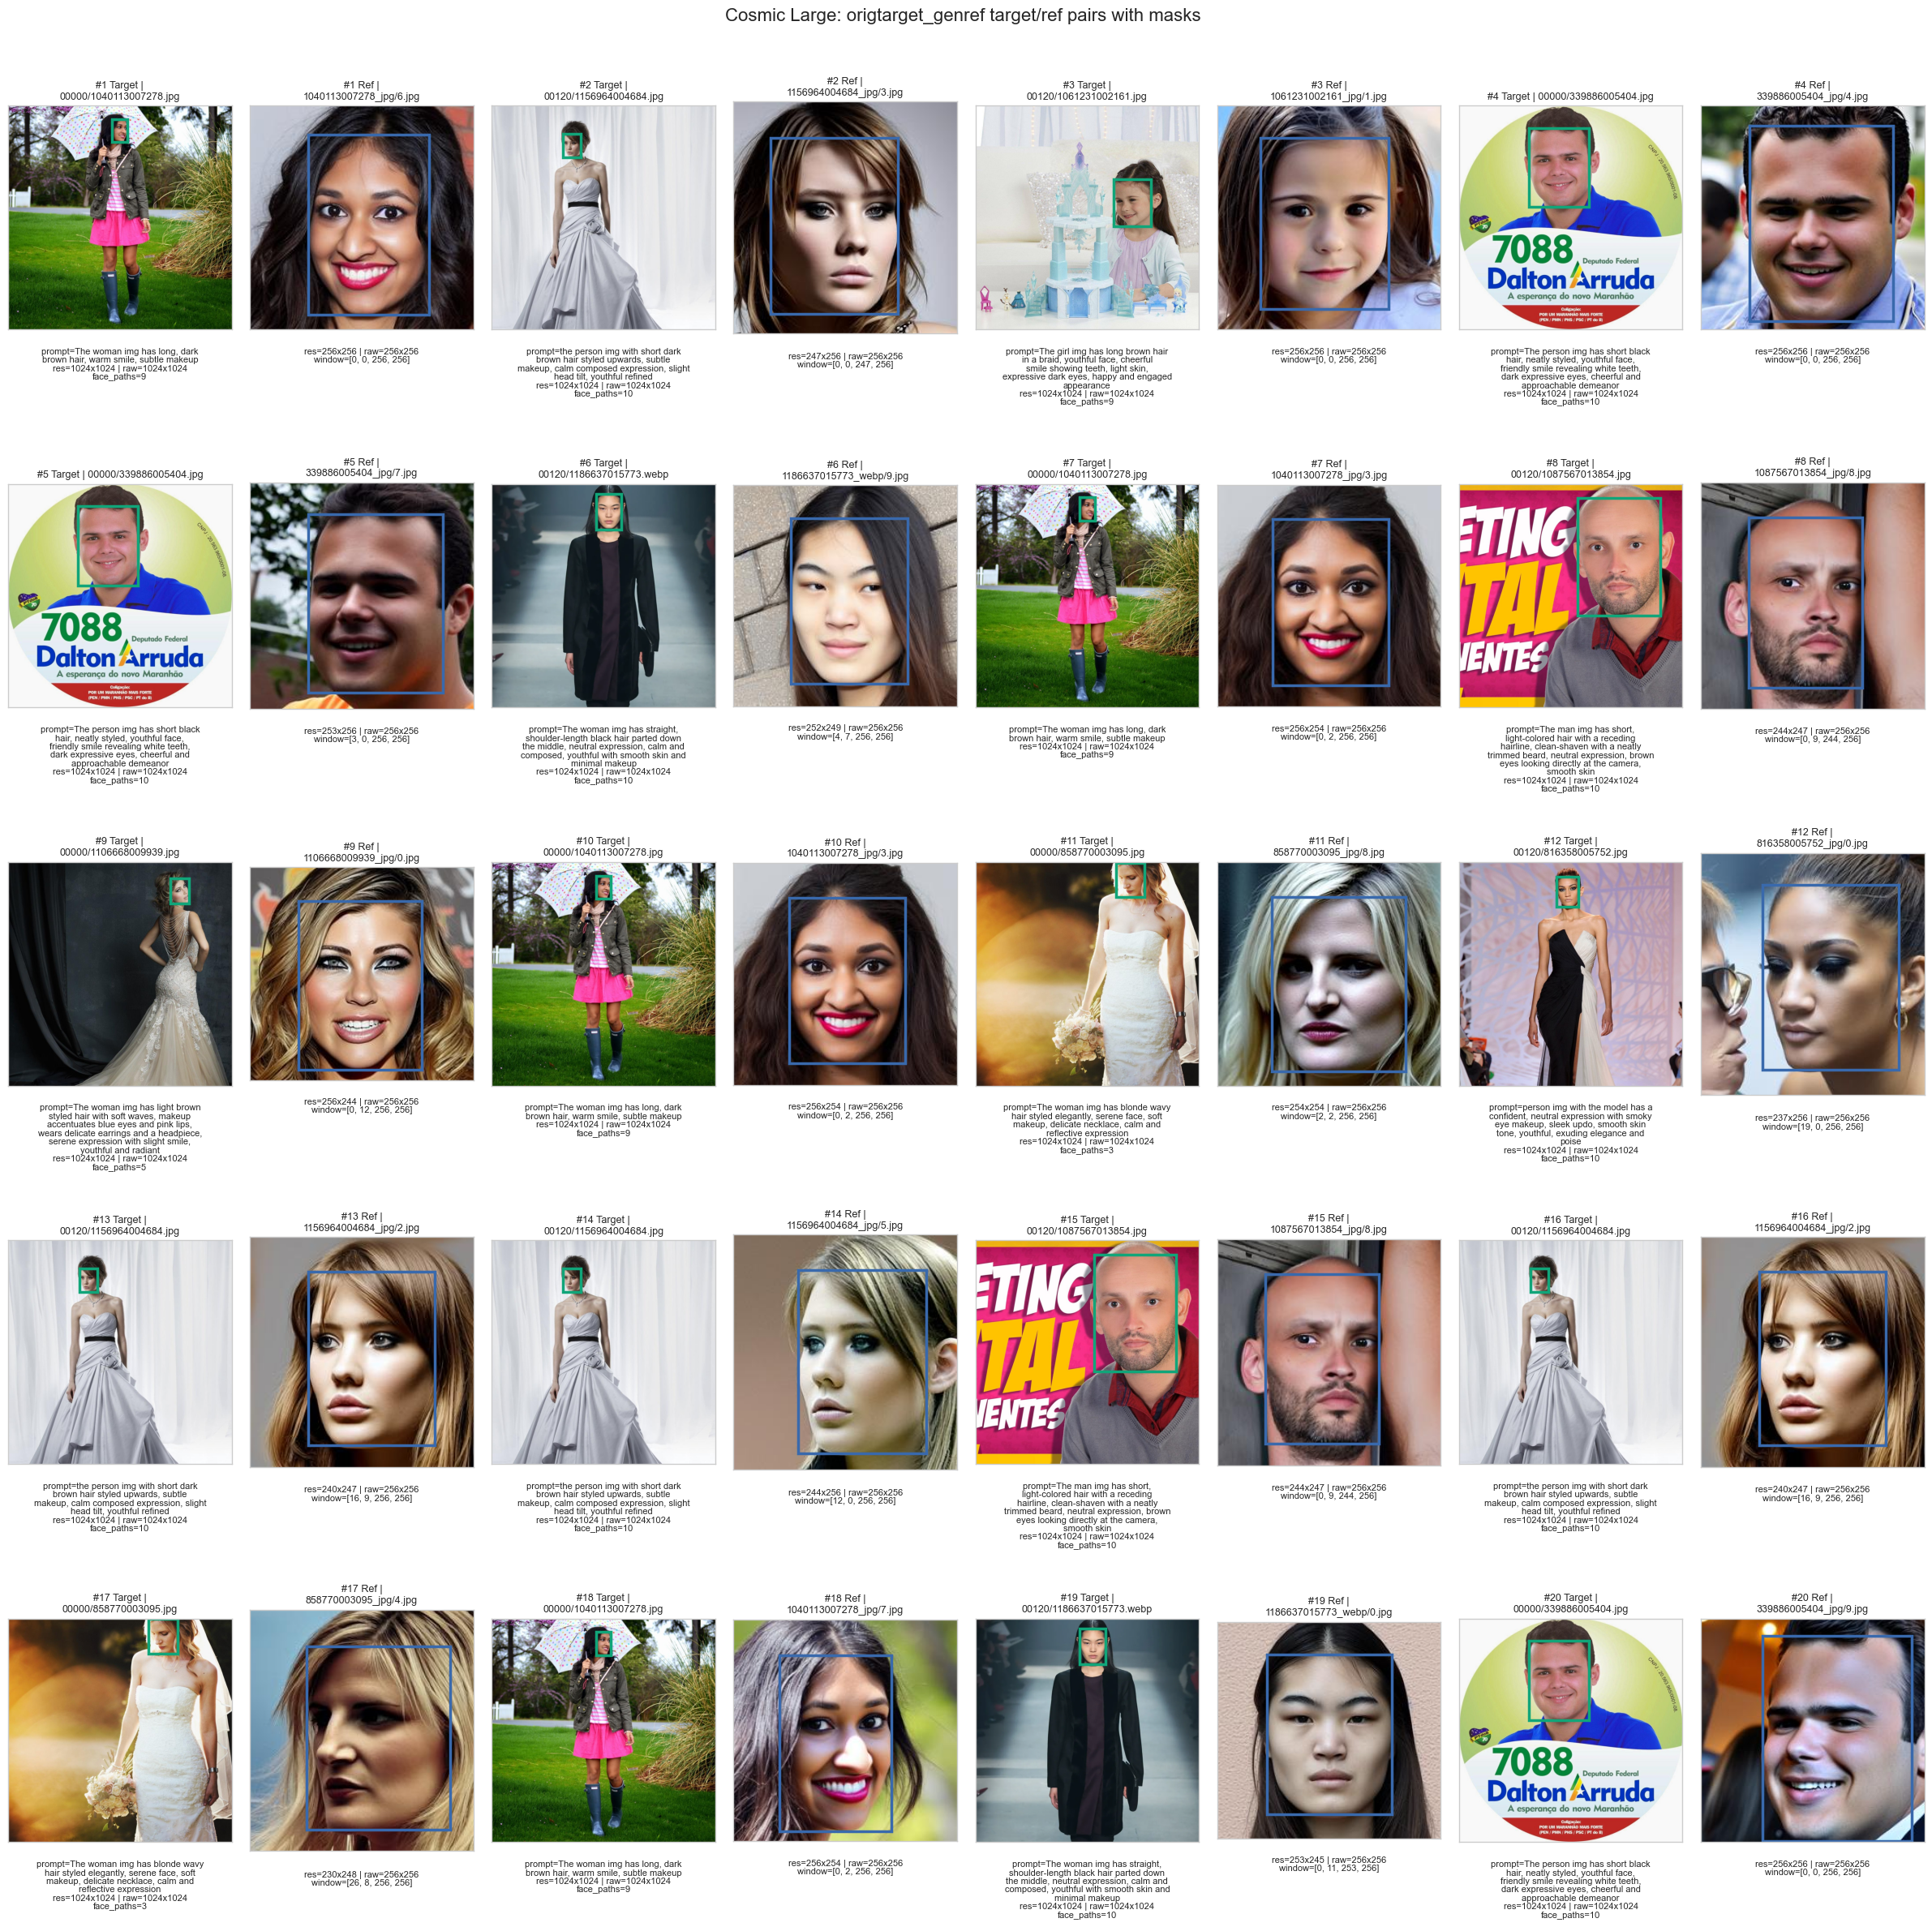

In [6]:
show_pair_grid(pairs_df, 'Cosmic Large: origtarget_genref target/ref pairs with masks')


## Quick Summary

In [7]:
summary_df = pd.DataFrame([
    {
        'pairs': len(pairs_df),
        'unique_records_sampled': int(pairs_df['record_key'].nunique()),
        'avg_target_width': float(np.mean([img.size[0] for img in pairs_df['target_img']])),
        'avg_target_height': float(np.mean([img.size[1] for img in pairs_df['target_img']])),
        'avg_ref_width': float(np.mean([img.size[0] for img in pairs_df['ref_img']])),
        'avg_ref_height': float(np.mean([img.size[1] for img in pairs_df['ref_img']])),
        'apply_random_flip': APPLY_RANDOM_FLIP,
    }
])
summary_df


,pairs,unique_records_sampled,avg_target_width,avg_target_height,avg_ref_width,avg_ref_height,apply_random_flip
0,20,9,1024.0,1024.0,249.3,251.9,False
